# Web Scraping & Exploratory Data Analysis — Practice Assignment

**Goal:** Scrape a small e-commerce/book dataset from the web, clean it with Pandas, and perform exploratory data analysis using statistics and visualizations.

### Rules
- Use Python, `requests`, `BeautifulSoup`, `pandas`, `matplotlib`, and `seaborn`.
- Write your own code in the provided answer cells.
- Add a short written interpretation wherever requested.
- Handle missing values/errors instead of assuming every page is perfect.

**Suggested source:** `https://books.toscrape.com/` — scrape at least **5 pages**.


## Part A — Setup (5 marks)
Import the libraries required for HTTP requests, HTML parsing, data handling, and plotting.


In [1]:
# Your imports here
import requests as rq
from bs4 import BeautifulSoup as BS
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

## Part B — Scraping (25 marks)
### Q1. Request the website
Create the base URL and headers. Request the first page and print the HTTP status code. If the request is unsuccessful, print a useful message.


In [2]:
base_url = "https://books.toscrape.com/"
urls = []
pages = 5

### Q2. Scrape multiple pages
Scrape **at least 5 pages**. From every book, collect:
- title
- price
- star rating
- availability

Store each book as a dictionary in a list. Avoid hard-coding individual book values.


In [3]:
for page in range(pages):
    extra_bit = f"catalogue/page-{page+1}.html"
    url = base_url + extra_bit
    urls.append(url)

In [4]:
web_pages = []
for url in urls:
    print(f"Scrapping: {url}")
    response = rq.get(url)
    print(f"exit status: {response.status_code}")
    soup = BS(response.text, "html.parser")
    web_pages.append(soup)

Scrapping: https://books.toscrape.com/catalogue/page-1.html
exit status: 200
Scrapping: https://books.toscrape.com/catalogue/page-2.html
exit status: 200
Scrapping: https://books.toscrape.com/catalogue/page-3.html
exit status: 200
Scrapping: https://books.toscrape.com/catalogue/page-4.html
exit status: 200
Scrapping: https://books.toscrape.com/catalogue/page-5.html
exit status: 200


### Q3. Create the DataFrame
Convert your collected records into a Pandas DataFrame. Display the first 10 rows, shape, column names, and data types.


In [5]:
product_names = []
product_prices = []
product_availability = [] 
product_ratings = []
for web_page in web_pages:
    products = web_page.find_all("article", class_ = "product_pod")
    for product in products:
        product_name = product.find("img").get("alt")
        product_price = product.find("p", class_ = "price_color").get_text()
        product_availability_ = "yes" if product.find("p", class_ = "instock availability") else "no"
        product_rating = product.find("p", class_ = "star-rating").get("class")[1]
        product_names.append(product_name)
        product_prices.append(product_price)
        product_availability.append(product_availability_)
        product_ratings.append(product_rating)

## Part C — Data Cleaning (15 marks)
### Q4. Clean the columns
1. Convert `price` from text such as `£51.77` to a numeric column.
2. Convert ratings (`One`, `Two`, ..., `Five`) to integers 1–5.
3. Convert availability into a useful representation of your choice.
4. Check for missing values and duplicates.
5. Remove/fix duplicates if any exist.


In [6]:
import pandas as pd

In [7]:
df = pd.DataFrame({
                    "title":product_names,
                    "price":product_prices,
                    "avail":product_availability,
                    "rating":product_ratings
                                                })

In [8]:
df.head()

,title,price,avail,rating
0,A Light in the Attic,Â£51.77,yes,Three
1,Tipping the Velvet,Â£53.74,yes,One
2,Soumission,Â£50.10,yes,One
3,Sharp Objects,Â£47.82,yes,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,yes,Five


In [9]:
df["price"] = df["price"].str[2:].astype(float)

In [10]:
df.head()

,title,price,avail,rating
0,A Light in the Attic,51.77,yes,Three
1,Tipping the Velvet,53.74,yes,One
2,Soumission,50.10,yes,One
3,Sharp Objects,47.82,yes,Four
4,Sapiens: A Brief History of Humankind,54.23,yes,Five


In [11]:
rating_map = {
              "One":1,
              "Two":2,
              "Three":3,
              "Four":4,
              "Five":5
                        }

df["rating"] = df["rating"].map(rating_map).astype(int)

In [12]:
df.head()

,title,price,avail,rating
0,A Light in the Attic,51.77,yes,3
1,Tipping the Velvet,53.74,yes,1
2,Soumission,50.10,yes,1
3,Sharp Objects,47.82,yes,4
4,Sapiens: A Brief History of Humankind,54.23,yes,5


### Q5. Export your cleaned dataset
Save the cleaned DataFrame as `books_assignment.csv` without the DataFrame index.


In [13]:
df.to_csv("web_scraping_eda_assignment.csv")

## Part D — Descriptive Analysis (20 marks)
### Q6. Summary statistics
Calculate and display:
- mean, median, minimum, maximum, and standard deviation of price
- mean and median rating
- number of books for each rating
- title and price of the most expensive book
- title and price of the cheapest book


In [14]:
df.dtypes

title      object
price     float64
avail      object
rating      int64
dtype: object

In [15]:
df["price"].describe()

count    100.000000
mean      34.560700
std       14.638531
min       10.160000
25%       19.897500
50%       34.775000
75%       47.967500
max       58.110000
Name: price, dtype: float64

In [16]:
df["rating"].describe()

count    100.000000
mean       2.930000
std        1.423149
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: rating, dtype: float64

In [17]:
df.isnull().sum()

title     0
price     0
avail     0
rating    0
dtype: int64

In [ ]:
df.groupby("rating")["price"].mean()

rating
1    35.519545
2    35.909474
3    36.839091
4    33.981667
5    30.012105
Name: price, dtype: float64

In [21]:
df.groupby("rating")["price"].count()

rating
1    22
2    19
3    22
4    18
5    19
Name: price, dtype: int64

In [25]:
df.loc[df["price"].idxmax()]

title     The Death of Humanity: and the Case for Life
price                                            58.11
avail                                              yes
rating                                               4
Name: 68, dtype: object

In [26]:
df.loc[df["price"].idxmin()]

title     Patience
price        10.16
avail          yes
rating           3
Name: 84, dtype: object

### Q7. Grouped analysis
Group books by rating and calculate the **average price**, **median price**, and **number of books** for each rating. Sort the result by rating.


In [28]:
df_aug = df.groupby("rating")

In [29]:
df_aug["price"].median()

rating
1    37.010
2    37.320
3    37.025
4    35.750
5    25.270
Name: price, dtype: float64

In [34]:
average = df_aug["price"].mean().sum()/5
average

np.float64(34.452376395534294)

In [32]:
df_aug["price"].median()

rating
1    37.010
2    37.320
3    37.025
4    35.750
5    25.270
Name: price, dtype: float64

### Q8. Correlation
Calculate the correlation between `price` and `rating`. In 2–3 sentences, explain what the sign and magnitude of your result suggest.


In [35]:
df["price"].corr(df["rating"])

np.float64(-0.12174127007413635)

**Interpretation:**  
Write your answer here.


## Part E — Visualization (25 marks)
### Q9. Price distribution
Create both:
1. a histogram of book prices, and
2. a KDE/PDF plot of book prices.

Give each graph a title and axis labels.


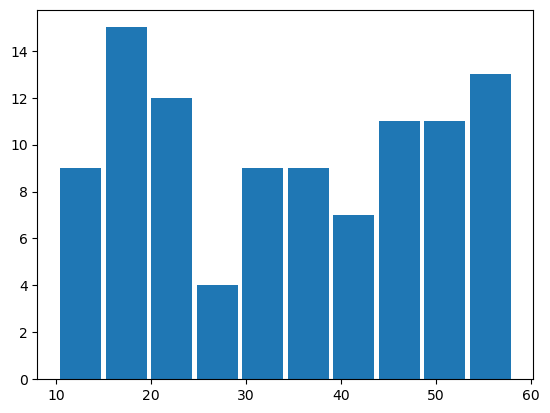

In [ ]:
plt.hist(df["price"] ,rwidth= 0.9)
plt.show()

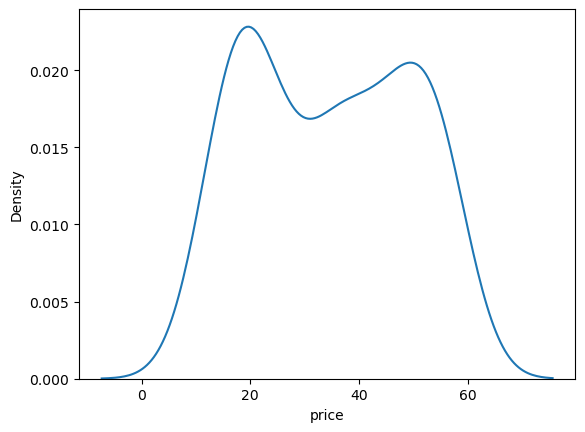

In [42]:
sns.kdeplot(df["price"])
plt.show()

### Q10. Rating analysis
Create a bar chart showing the **average price for each star rating**.


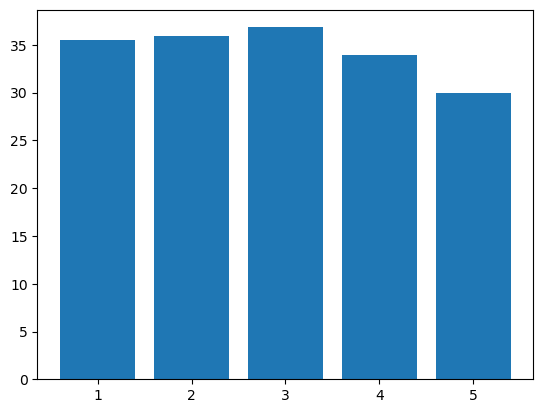

In [53]:
plt.bar(df.groupby("rating")["price"].mean().index, df.groupby("rating")["price"].mean().values)
plt.show()

### Q11. Price vs rating
Create a scatter plot of price versus rating. Briefly compare what you see with the correlation calculated in Q8.


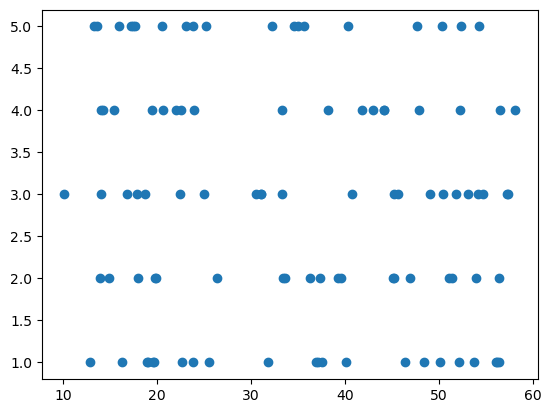

In [54]:
plt.scatter(df["price"], df["rating"])
plt.show()

**Interpretation:**  
Write your answer here.


## Part F — Skewness & Outliers (10 marks)
### Q12. Skewness
Calculate the skewness of the price distribution. State whether it is approximately symmetric, positively skewed, or negatively skewed.


In [55]:
df["price"].skew()

np.float64(0.04314307671965572)

**Interpretation:**  
Write your answer here.


### Q13. Outlier analysis
Use the **IQR method** to identify price outliers. Print:
- Q1
- Q3
- IQR
- lower and upper bounds
- number of detected outliers
- the titles and prices of all detected outliers

Then create a box plot of price.


In [58]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df [(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [title, price, avail, rating]
Index: []


## Bonus — Challenge (up to 10 marks)
Choose **one**:

**A. Category analysis:** Visit each book detail page, scrape its category, and determine which category has the highest average price.

**B. More data:** Scrape all available catalogue pages and compare your full-dataset results with the first-five-pages results.

**C. Your own question:** Formulate one meaningful question about the dataset, answer it using analysis/visualization, and explain your conclusion.


## Submission checklist
Before submitting, restart the kernel and run all cells from top to bottom. Make sure the notebook runs without errors, graphs have labels/titles, interpretations are written, and `books_assignment.csv` is generated.
